In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("../data/raw/Student Social Media And Mental Health Impact.csv")


In [3]:
df_train = pd.read_csv('../data/processed/train_limpio.csv')
df_test = pd.read_csv('../data/processed/test_limpio.csv')


## Paso 6: Construcción y optimización del modelo 

In [4]:
X_train = df_train.drop(columns='Stress_Level')
X_test = df_test.drop(columns='Stress_Level')
y_train = df_train['Stress_Level']
y_test = df_test['Stress_Level']

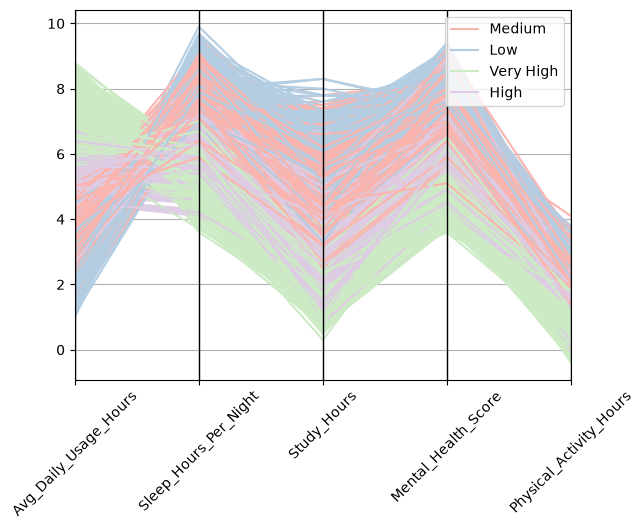

In [5]:
import pandas as pd

X = df[[
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Study_Hours",
    "Mental_Health_Score",
    "Physical_Activity_Hours"
]]

y = df["Stress_Level"]


pd.plotting.parallel_coordinates(
    X.assign(Stress_Level=y), "Stress_Level", color=["#FBB4AE", "#B3CDE3", "#CCEBC5", "#DECBE4"]).tick_params(axis='x', rotation=45)

Como habíamos mencionado en el EDA, debido a la alta multicolinealidad entre nuestras variables, vamos a utilizar modelos relacionados a Árboles y probaremos tres de ellos: Árbol de Decisión, Random Forest y XGBoost. Iremos desarrollando uno a uno a continuación.


### Árbol de Decisión:

**Inicialización y entrenamiento del modelo**

In [6]:
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = DecisionTreeClassifier(random_state = 42)
modelo_arbol.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

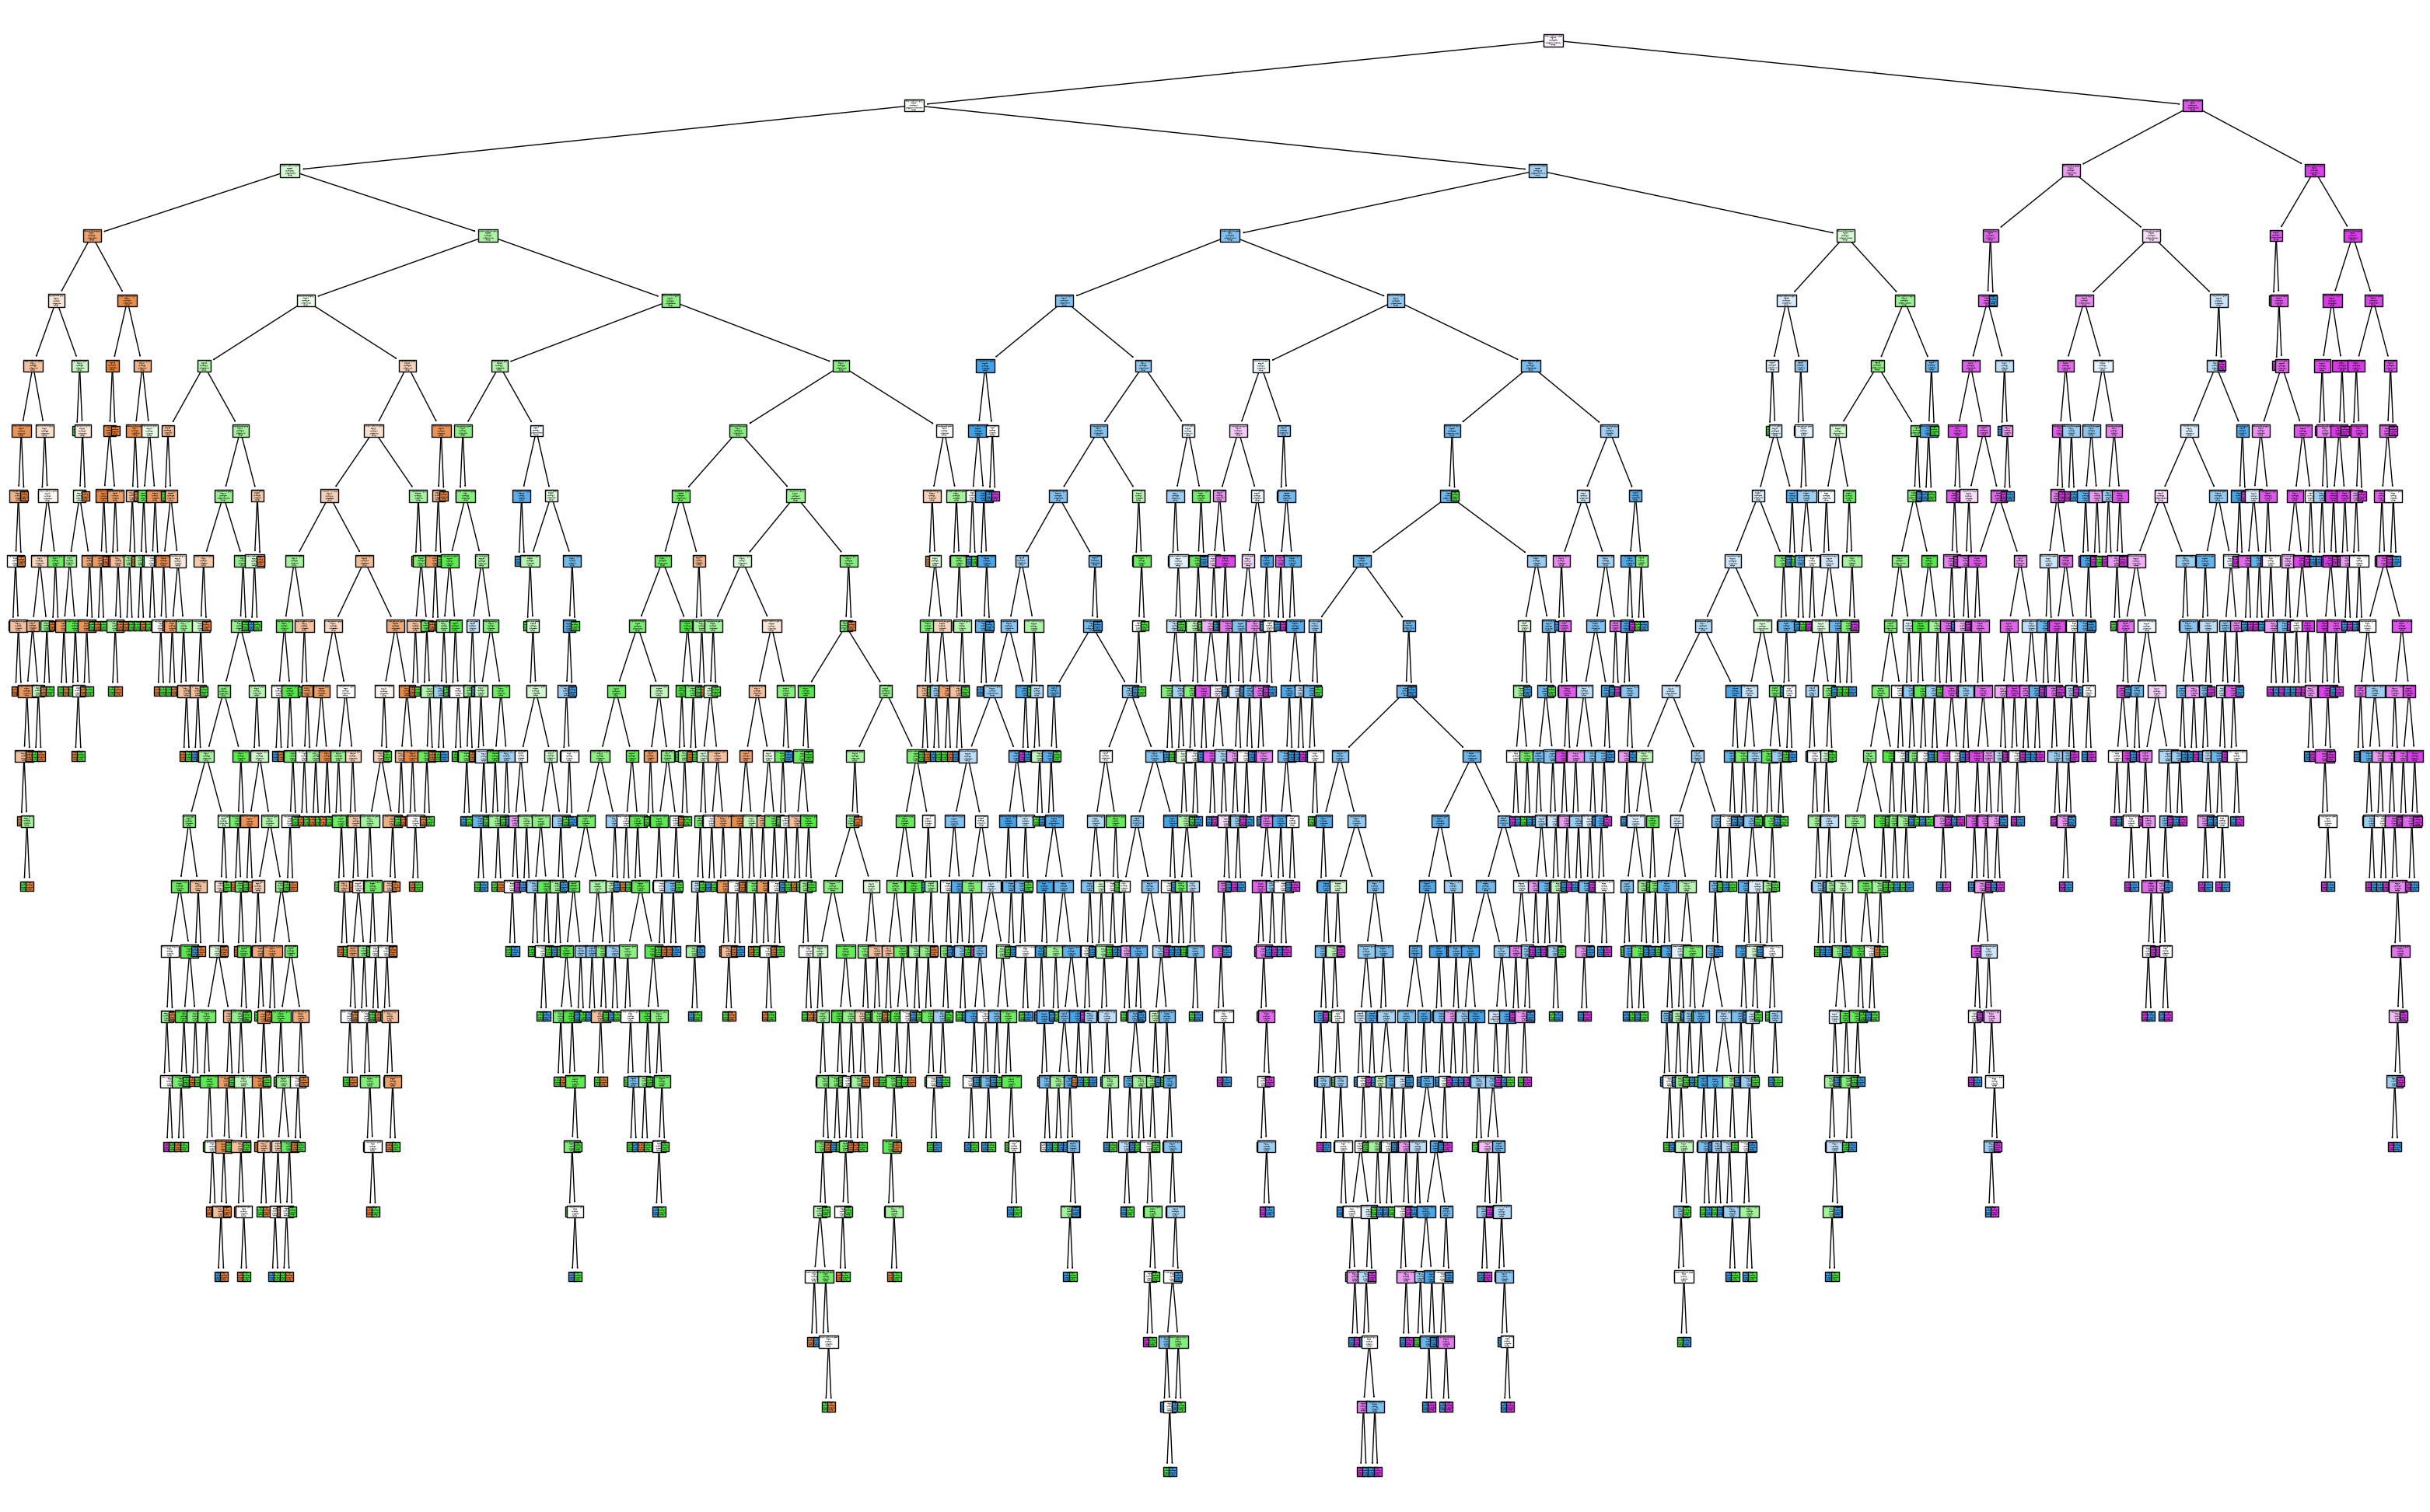

In [7]:
import matplotlib.pyplot as plt
from sklearn import tree

fig = plt.figure(figsize=(40,25))

tree.plot_tree(modelo_arbol, feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True)

plt.show()

Debido a que nuestro árbol es extremadamente grande/profundo con demasiadas ramas para visibilizarlas todas en detalle, vamos a limitar la profundidad para presentarlo de forma más clara, mostrando sólo los primeros 3 niveles del árbol, que son los más importantes para interpretar qué variables utiliza primero para clasificar 'Stress_Level'.

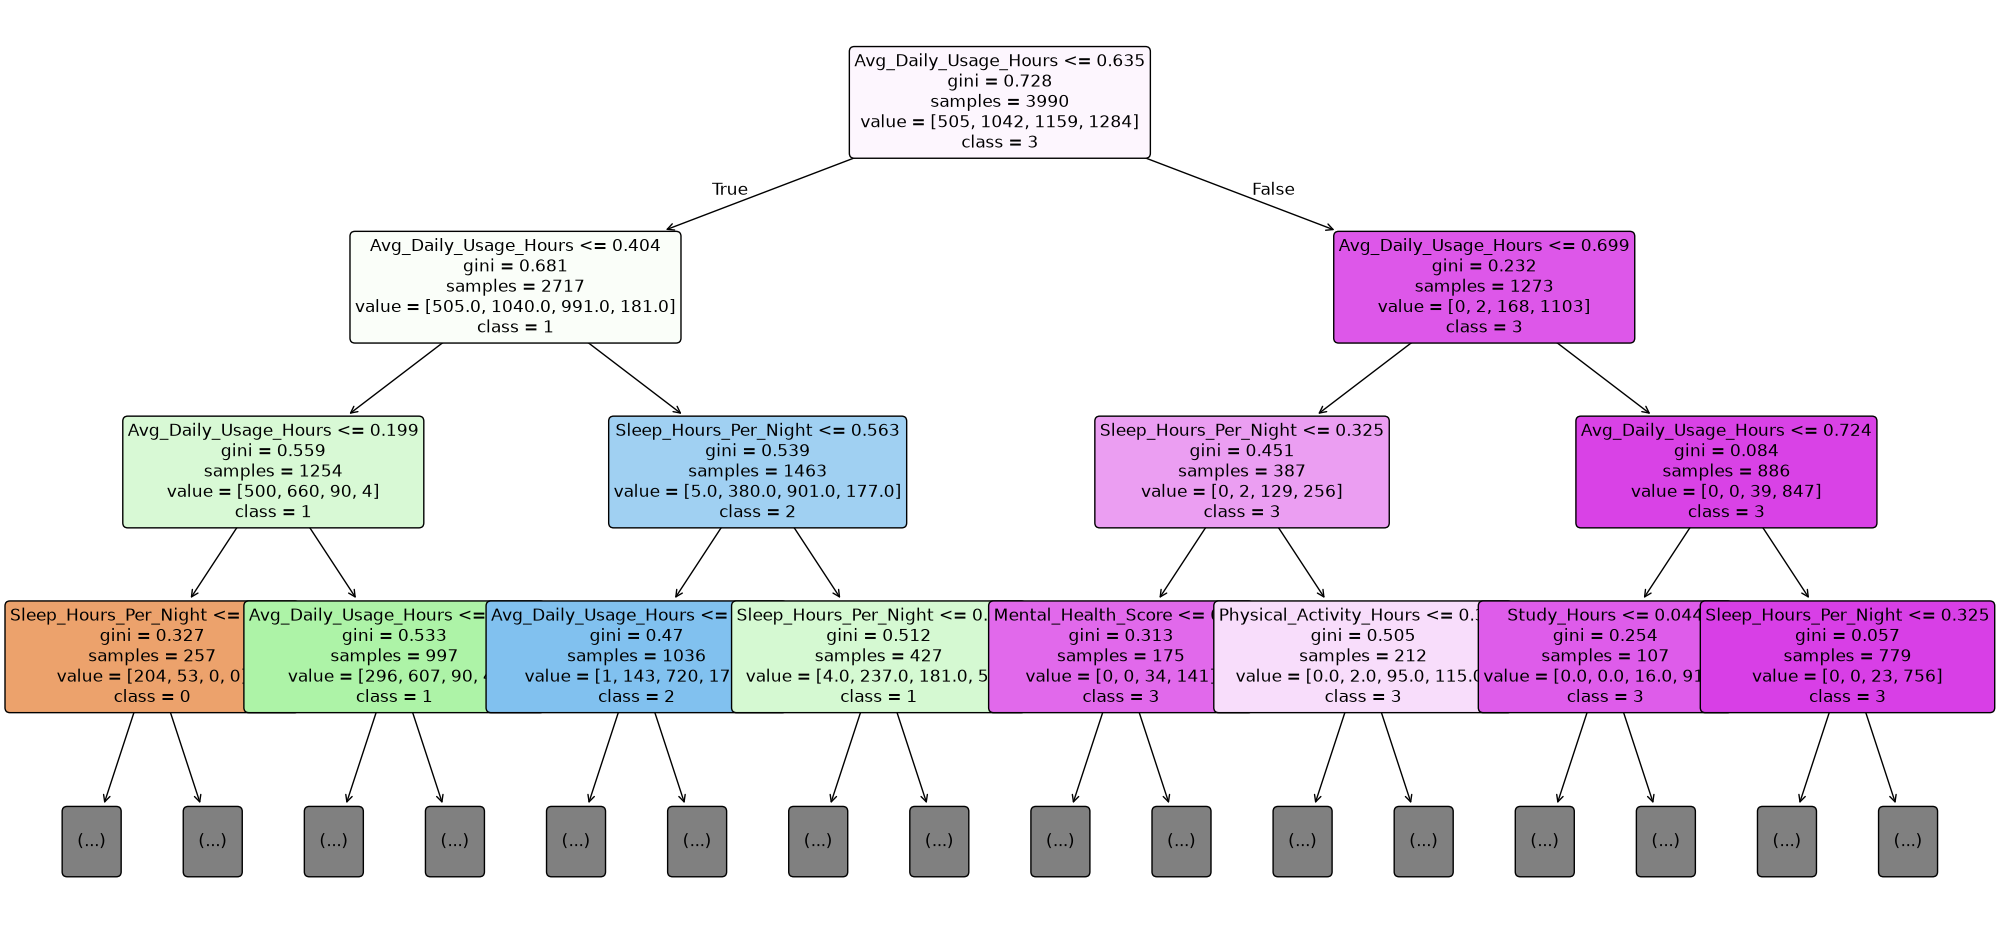

In [8]:

fig = plt.figure(figsize=(25, 12))

tree.plot_tree(modelo_arbol, feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True,rounded=True, max_depth=3, fontsize=12)

plt.show()



**Predicción del Modelo:**

In [9]:
y_pred_arbol = modelo_arbol.predict(X_test)
y_pred_arbol

array([3, 3, 2, 2, 3, 2, 2, 1, 0, 1, 3, 2, 0, 3, 2, 0, 0, 3, 3, 3, 1, 1,
       2, 2, 2, 3, 2, 3, 2, 1, 2, 1, 3, 2, 3, 0, 3, 1, 1, 3, 1, 1, 3, 2,
       1, 1, 2, 2, 3, 3, 1, 3, 2, 1, 1, 1, 0, 3, 3, 2, 3, 0, 3, 2, 1, 3,
       3, 0, 2, 1, 2, 2, 3, 2, 3, 3, 2, 0, 2, 1, 3, 2, 2, 3, 2, 2, 3, 3,
       3, 2, 3, 2, 2, 3, 2, 1, 2, 0, 1, 0, 0, 1, 2, 1, 2, 2, 2, 1, 1, 1,
       3, 1, 3, 0, 2, 1, 1, 2, 1, 2, 2, 2, 0, 3, 2, 2, 3, 1, 0, 2, 0, 2,
       1, 0, 0, 2, 3, 1, 3, 0, 2, 1, 3, 0, 3, 2, 1, 2, 2, 3, 2, 3, 2, 3,
       3, 2, 3, 2, 0, 2, 3, 0, 2, 2, 2, 0, 1, 1, 3, 1, 0, 1, 3, 3, 0, 0,
       1, 0, 1, 3, 3, 3, 3, 0, 1, 3, 2, 0, 0, 0, 1, 2, 3, 3, 0, 1, 2, 1,
       2, 3, 1, 3, 3, 1, 2, 3, 3, 2, 1, 0, 1, 0, 3, 0, 3, 1, 2, 0, 2, 2,
       0, 2, 3, 3, 2, 1, 1, 1, 3, 3, 3, 0, 3, 1, 3, 1, 3, 1, 1, 1, 0, 3,
       0, 0, 3, 1, 3, 3, 3, 1, 2, 0, 3, 2, 1, 2, 2, 1, 3, 2, 0, 1, 1, 0,
       2, 3, 2, 2, 2, 2, 0, 3, 0, 1, 1, 3, 2, 3, 1, 3, 1, 1, 2, 3, 1, 3,
       3, 3, 3, 0, 3, 0, 0, 1, 3, 3, 3, 3, 1, 2, 0,

In [10]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

print(accuracy_score(y_test, y_pred_arbol))
print(f1_score(y_test, y_pred_arbol, average='weighted'))
print(recall_score(y_test, y_pred_arbol, average='weighted'))

0.7084168336673347
0.7089218872512044
0.7084168336673347


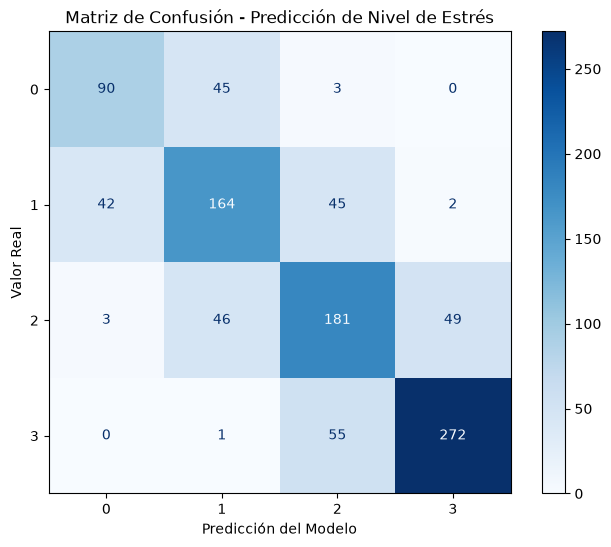

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_arbol)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_arbol.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Matriz de Confusión - Predicción de Nivel de Estrés')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

**Optimización del modelo**

In [15]:
arbol = DecisionTreeClassifier(random_state=42)

param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": [None, "sqrt", "log2"]
}

In [16]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=arbol,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [17]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [2, 3, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callabl

In [18]:
print("Mejores hiperparámetros:", grid_search.best_params_)

print("\nMejor Accuracy en Cross-Validation:", grid_search.best_score_)

Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}

Mejor Accuracy en Cross-Validation: 0.7368421052631579


In [28]:
modelo_arbol_opt = grid_search.best_estimator_

y_pred_opt_arbol = modelo_arbol_opt.predict(X_test)

print(accuracy_score(y_test, y_pred_opt_arbol))
print(f1_score(y_test, y_pred_opt_arbol, average='weighted'))
print(recall_score(y_test, y_pred_opt_arbol, average='weighted'))

0.718436873747495
0.7179187357156299
0.718436873747495


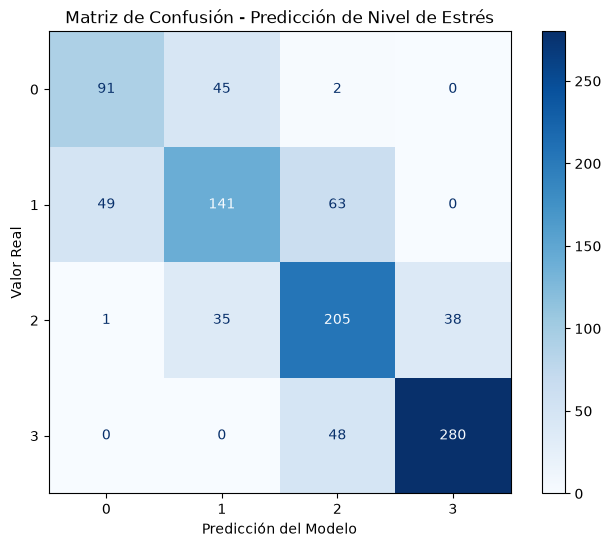

In [31]:
cm = confusion_matrix(y_test, y_pred_opt_arbol)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_arbol_opt.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Matriz de Confusión - Predicción de Nivel de Estrés')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

**Guardado del modelo**

In [33]:
from pickle import dump

dump(modelo_arbol, open("decision_tree_classifier_default_42.sav", "wb"))

### Random Forest:

**Inicialización y entrenamiento del modelo**

In [34]:
from sklearn.ensemble import RandomForestClassifier

modelo_random_forest = RandomForestClassifier(random_state = 42)
modelo_random_forest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

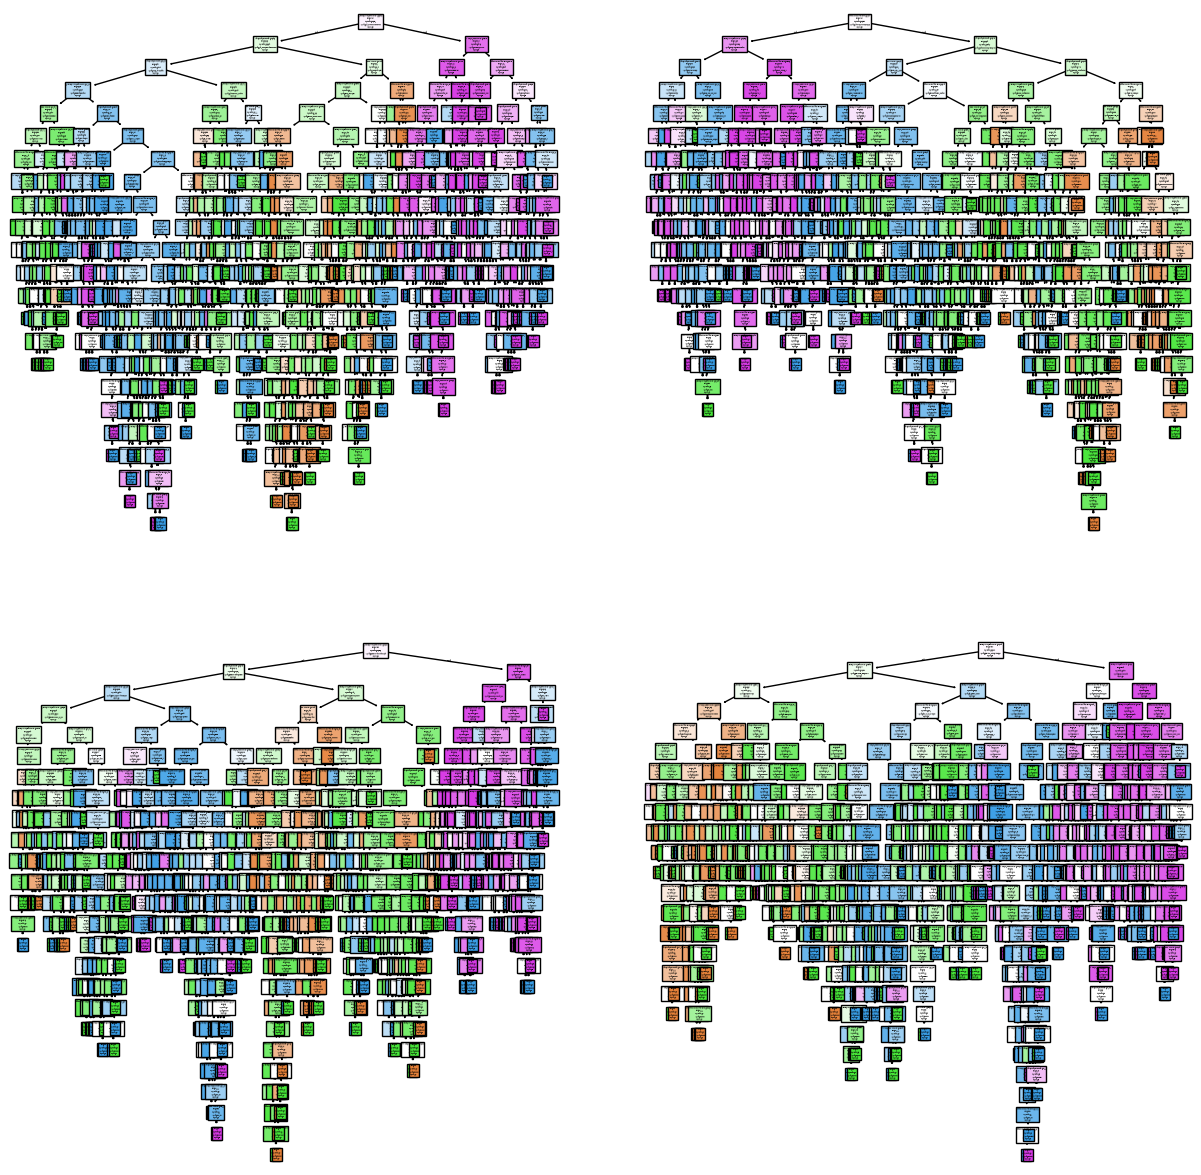

In [24]:
fig, axis = plt.subplots(2, 2, figsize = (15, 15))

tree.plot_tree(modelo_random_forest.estimators_[0], ax = axis[0, 0], feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True)
tree.plot_tree(modelo_random_forest.estimators_[1], ax = axis[0, 1], feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True)
tree.plot_tree(modelo_random_forest.estimators_[2], ax = axis[1, 0], feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True)
tree.plot_tree(modelo_random_forest.estimators_[3], ax = axis[1, 1], feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True)

plt.show()

Debido a que nuevamente nuestros árboles son extremadamente grande/profundo con demasiadas ramas para visibilizarlas todas en detalle, vamos a limitar la profundidad para presentarlos de forma más clara, mostrando sólo los primeros 3 niveles de ellos, que son los más importantes para interpretar qué variables utiliza primero para clasificar 'Stress_Level'.

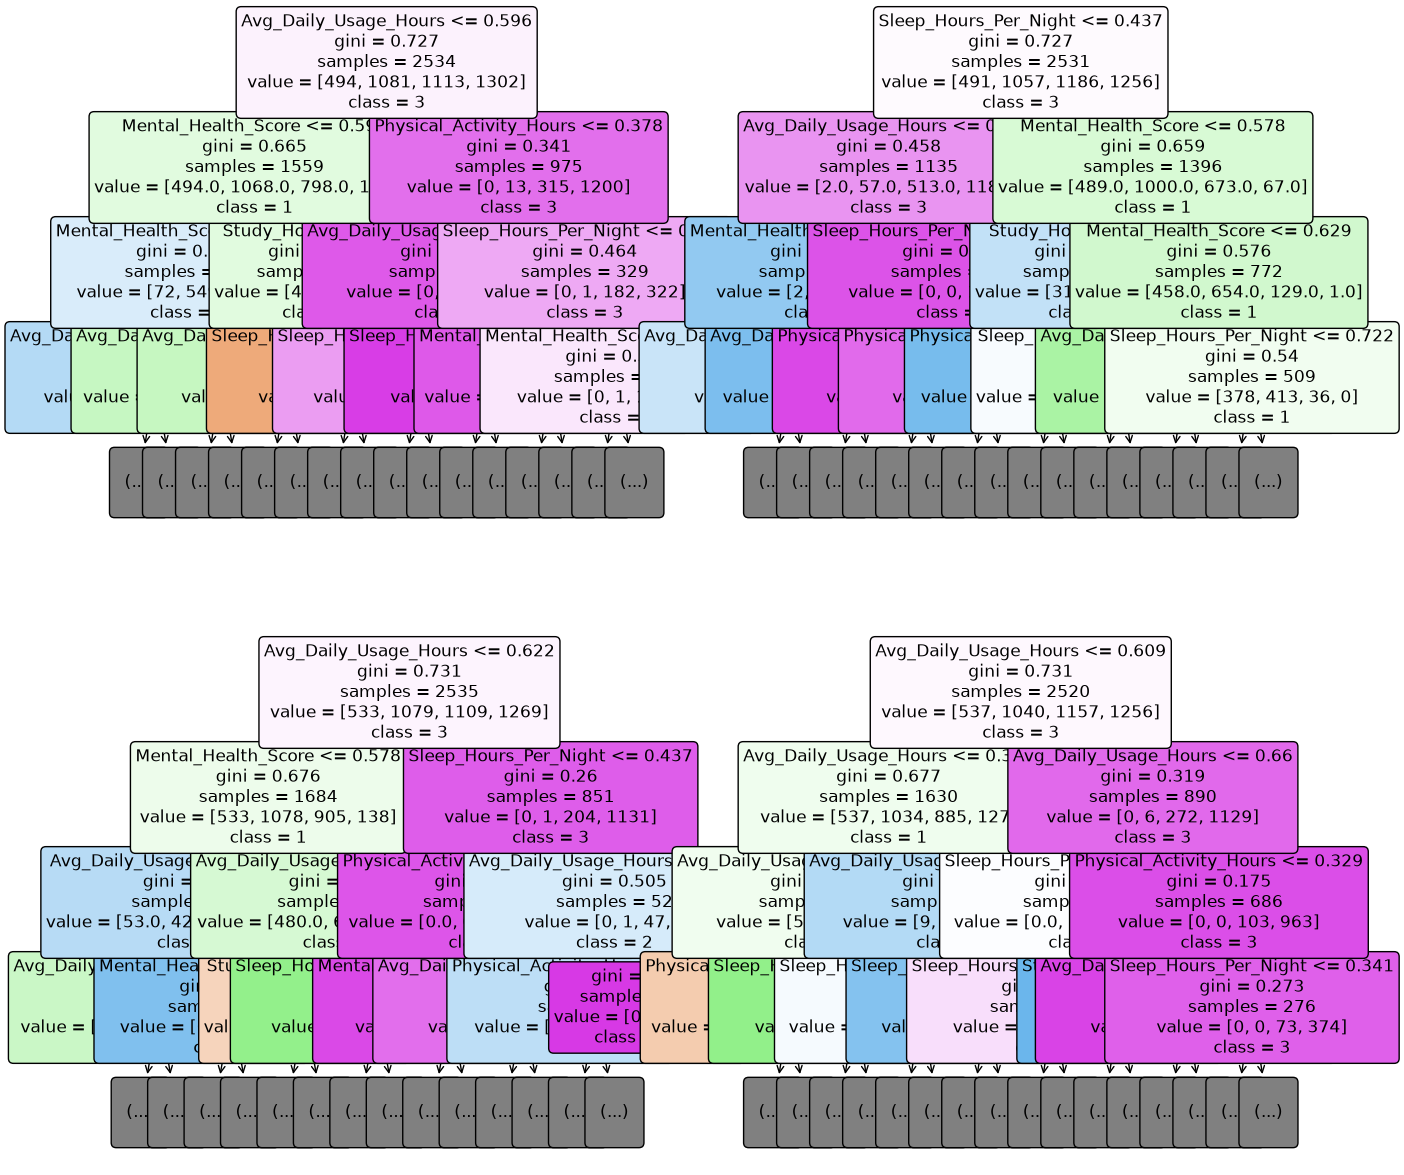

In [ ]:
fig, axis = plt.subplots(2, 2, figsize = (15, 15))

tree.plot_tree(modelo_random_forest.estimators_[0], ax = axis[0, 0], feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True, rounded=True, max_depth=3, fontsize=12)
tree.plot_tree(modelo_random_forest.estimators_[1], ax = axis[0, 1], feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True, rounded=True, max_depth=3, fontsize=12)
tree.plot_tree(modelo_random_forest.estimators_[2], ax = axis[1, 0], feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True, rounded=True, max_depth=3, fontsize=12)
tree.plot_tree(modelo_random_forest.estimators_[3], ax = axis[1, 1], feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3"], filled = True, rounded=True, max_depth=3, fontsize=12)

plt.show()

**Predicción del modelo**

In [35]:
y_pred_random_forest = modelo_random_forest.predict(X_test)
y_pred_random_forest

array([3, 3, 3, 1, 3, 2, 2, 1, 0, 1, 3, 2, 1, 3, 2, 0, 1, 3, 3, 3, 1, 1,
       2, 2, 2, 3, 2, 3, 3, 1, 2, 1, 3, 2, 3, 1, 3, 1, 1, 3, 1, 0, 3, 2,
       1, 1, 1, 2, 3, 3, 2, 3, 3, 1, 1, 1, 0, 3, 3, 2, 3, 0, 3, 1, 0, 3,
       3, 0, 2, 2, 3, 3, 3, 2, 3, 3, 2, 1, 2, 1, 3, 2, 2, 3, 2, 3, 3, 3,
       3, 2, 3, 2, 2, 3, 2, 0, 2, 0, 1, 1, 0, 1, 2, 1, 2, 2, 2, 1, 1, 0,
       3, 0, 3, 0, 2, 2, 1, 3, 1, 2, 2, 1, 0, 2, 2, 2, 3, 2, 1, 2, 1, 2,
       1, 0, 0, 1, 3, 2, 3, 0, 2, 1, 3, 0, 3, 3, 0, 2, 2, 3, 1, 3, 2, 3,
       3, 2, 3, 2, 0, 2, 3, 0, 1, 2, 2, 1, 1, 1, 3, 1, 0, 1, 3, 2, 0, 0,
       1, 0, 1, 3, 3, 3, 3, 0, 2, 3, 2, 0, 0, 0, 2, 2, 3, 3, 0, 0, 2, 1,
       3, 3, 1, 3, 3, 1, 2, 3, 2, 2, 0, 1, 1, 0, 3, 0, 3, 1, 2, 0, 2, 2,
       1, 2, 3, 3, 1, 1, 2, 1, 3, 2, 3, 0, 3, 1, 3, 1, 2, 0, 1, 1, 0, 2,
       0, 1, 3, 2, 3, 3, 3, 1, 2, 0, 3, 2, 2, 2, 2, 1, 3, 2, 0, 2, 0, 0,
       1, 3, 2, 2, 3, 2, 0, 3, 0, 1, 1, 3, 2, 3, 1, 3, 1, 0, 2, 3, 1, 3,
       2, 3, 3, 1, 3, 0, 1, 1, 2, 3, 3, 3, 0, 3, 0,

In [36]:
print(accuracy_score(y_test, y_pred_random_forest))
print(f1_score(y_test, y_pred_random_forest, average='weighted'))
print(recall_score(y_test, y_pred_random_forest, average='weighted'))

0.7474949899799599
0.7472744257708389
0.7474949899799599


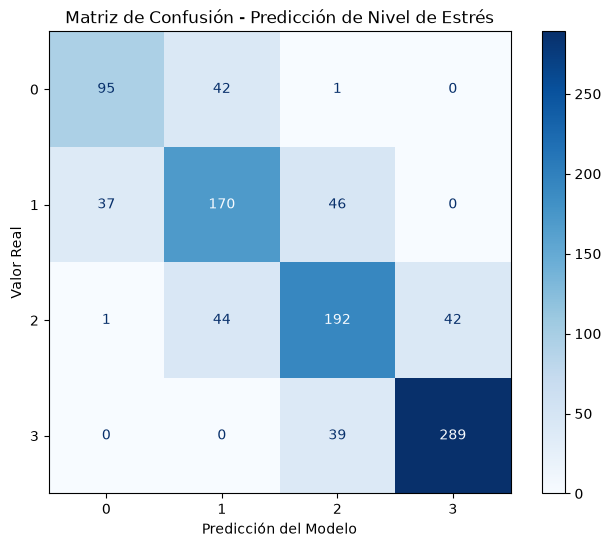

In [37]:
cm = confusion_matrix(y_test, y_pred_random_forest)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_random_forest.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Matriz de Confusión - Predicción de Nivel de Estrés')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

**Optimización del modelo**

In [38]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

In [39]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1944 candidates, totalling 9720 fits


In [ ]:
print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor puntuación:", grid_search.best_score_)

In [ ]:
modelo_random_forest_opt = grid_search.best_estimator_

y_pred_random_forest_opt = modelo_random_forest_opt.predict(X_test)

print(accuracy_score(y_test, y_pred_random_forest_opt))
print(f1_score(y_test, y_pred_random_forest_opt, average='weighted'))
print(recall_score(y_test, y_pred_random_forest_opt, average='weighted'))

In [ ]:
cm = confusion_matrix(y_test, y_pred_random_forest_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_random_forest_opt.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Matriz de Confusión - Predicción de Nivel de Estrés')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

**Guardado del modelo**

In [ ]:
from pickle import dump

dump(modelo_random_forest_opt, open("random_forest_classifier_default_42.sav", "wb"))